# Precio y volumen — AVE FÉNIX · Premium
### Enero – agosto 2026

Volumen diario de Premium contra el precio propio y el de SERVICIO PETRO JUNÍPERO.

**Especificación**

$$\ln(\text{litros}) = \alpha + \beta_{m}\ln\!\left(\tfrac{p_{\text{propio}}+p_{\text{comp}}}{2}\right) + \beta_{p}\,(p_{\text{propio}}-p_{\text{comp}}) + \theta\ln(\text{litros}_{t-365}) + \gamma\,\text{Quincena} + \delta\,\text{Festivo} + \sum D_{\text{día}} + \tau t + \varepsilon$$

| Parámetro | Unidad |
|---|---|
| $\beta_m$ | % de volumen por 1% de precio de la zona |
| $\beta_p$ | % de volumen por \$1 de diferencia contra el competidor |

**Notas de método.** Sin armónicos de Fourier: requieren 365+ días y aquí hay ~230.
La estacionalidad anual se controla con el volumen del mismo día del año anterior.
Errores estándar HAC (Newey-West, 14 rezagos).

## 0 · Preparación

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.stats.diagnostic import het_breuschpagan

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["text.parse_math"] = False
pd.set_option("display.width", 150)

sys.path.insert(0, str(Path.cwd().parent / "codigo"))   # el paquete vive en <raíz>/codigo
from treher_analytics import data, config as cfg

ESTACION   = "AVE FENIX"
COMPETIDOR = "SERVICIO PETRO JUNIPERO"
COLS_LTS   = {"Premium": "Premium (Lts)", "Regular": "Regular (Lts)"}
COL_PRE_P  = "Precio P"
MARGEN_L   = 2.50          # <-- margen unitario supuesto de Premium

## 1 · Precios de la competencia

Definidos por tramos `(desde, hasta, competencia, AVE FÉNIX)`. Los días sin dato están
declarados en `HUECOS`. Fuente: `PRECIOS COMPETENCIA 2026.xlsb`, hoja `DB P_Competencia`.

In [2]:
TRAMOS = [
    ("2026-01-01", "2026-01-15", 24.99, 24.99),
    ("2026-01-16", "2026-01-23", 24.44, 24.99),
    ("2026-01-24", "2026-01-29", 24.99, 24.99),
    ("2026-01-30", "2026-02-02", 24.99, 24.84),
    ("2026-02-04", "2026-02-20", 24.99, 24.84),
    ("2026-02-21", "2026-02-26", 24.99, 24.89),
    ("2026-03-01", "2026-03-06", 24.99, 24.89),
    ("2026-03-07", "2026-03-08", 24.99, 24.94),
    ("2026-03-12", "2026-03-12", 24.49, 25.29),
    ("2026-03-13", "2026-03-15", 24.79, 25.29),
    ("2026-03-16", "2026-03-17", 25.99, 25.29),
    ("2026-03-18", "2026-03-19", 26.89, 26.99),
    ("2026-03-20", "2026-03-21", 26.89, 27.39),
    ("2026-03-22", "2026-03-23", 27.44, 27.39),
    ("2026-03-24", "2026-03-27", 27.44, 27.69),
    ("2026-03-28", "2026-03-30", 27.64, 27.99),
    ("2026-03-31", "2026-03-31", 27.94, 27.99),
    ("2026-04-01", "2026-04-09", 27.94, 28.34),
    ("2026-04-10", "2026-04-20", 27.94, 28.44),
    ("2026-04-21", "2026-04-21", 27.94, 28.19),
    ("2026-04-22", "2026-04-23", 27.99, 28.19),
    ("2026-04-24", "2026-04-28", 27.99, 27.99),
    ("2026-04-29", "2026-05-18", 27.99, 28.29),
    ("2026-05-19", "2026-05-27", 27.89, 28.29),
    ("2026-05-28", "2026-06-02", 27.94, 28.29),
    ("2026-06-04", "2026-06-24", 27.94, 28.29),
    ("2026-06-25", "2026-06-26", 27.99, 28.29),
    ("2026-06-29", "2026-07-06", 27.99, 28.29),
    ("2026-07-10", "2026-07-13", 28.04, 28.29),
    ("2026-07-14", "2026-07-14", 27.74, 28.29),
    ("2026-07-15", "2026-07-20", 27.59, 28.29),
    ("2026-07-21", "2026-07-31", 27.44, 28.29),
    ("2026-08-01", "2026-08-05", 27.89, 28.29),
    ("2026-08-06", "2026-08-12", 28.19, 28.29),
    ("2026-08-13", "2026-08-17", 28.29, 28.29),
    ("2026-08-18", "2026-08-24", 27.89, 28.29),
    ("2026-08-25", "2026-08-31", 28.09, 28.29),
]
HUECOS = ["2026-02-03", "2026-02-27", "2026-02-28",
          "2026-03-09", "2026-03-10", "2026-03-11",
          "2026-06-03", "2026-06-27", "2026-06-28",
          "2026-07-07", "2026-07-08", "2026-07-09"]

filas = [{"Fecha": f, "precio_comp": jun, "af_archivo": af}
         for ini, fin, jun, af in TRAMOS
         for f in pd.date_range(ini, fin, freq="D")]
comp = (pd.DataFrame(filas)
        .query("Fecha not in @pd.to_datetime(@HUECOS)")
        .drop_duplicates("Fecha").sort_values("Fecha").reset_index(drop=True))

esperados = (comp.Fecha.max() - comp.Fecha.min()).days + 1 - len(HUECOS)
print(f"días        : {len(comp)}   ({comp.Fecha.min():%d/%m/%Y} a {comp.Fecha.max():%d/%m/%Y})")
print(f"cuadre      : {len(comp)} generados / {esperados} esperados -> "
      f"{'OK' if len(comp) == esperados else 'REVISAR'}")
print(f"cambios     : competencia {int((comp.precio_comp.diff()!=0).sum()-1)} · "
      f"AVE FÉNIX {int((comp.af_archivo.diff()!=0).sum()-1)}")

días        : 231   (01/01/2026 a 31/08/2026)
cuadre      : 231 generados / 231 esperados -> OK
cambios     : competencia 22 · AVE FÉNIX 13


## 2 · Cruce con ventas

El precio propio se toma de la BD. El del archivo de competencia sólo se usa para contrastar las dos fuentes.

In [3]:
bd = data.cargar_bd()
COLS_LTS["Diesel"] = [c for c in bd.columns
                      if c.lower().startswith("di") and "lts" in c.lower()][0]
P = COLS_LTS["Premium"]

est = (bd[bd[cfg.COL_ESTACION] == ESTACION]
       .sort_values(cfg.COL_FECHA).reset_index(drop=True))
est = est[est["Operó"]].copy()

df = est.merge(comp, left_on=cfg.COL_FECHA, right_on="Fecha", how="inner").copy()
df["pos"]     = df[COL_PRE_P] - df["precio_comp"]
df["p_medio"] = (df[COL_PRE_P] + df["precio_comp"]) / 2

print(f"traslape: {len(df)} días · {df[cfg.COL_FECHA].min():%d/%m/%Y} a "
      f"{df[cfg.COL_FECHA].max():%d/%m/%Y}\n")

dif = (df[COL_PRE_P] - df["af_archivo"]).abs()
print(f"precio propio · BD vs archivo de competencia")
print(f"  dif. media {dif.mean():.4f} · máxima {dif.max():.2f} · "
      f"días con |dif| > $0.05: {(dif > 0.05).sum()} de {len(df)}")
if (dif > 0.05).any():
    print()
    print(df.loc[dif > 0.05, [cfg.COL_FECHA, COL_PRE_P, "af_archivo"]]
            .assign(dif=lambda x: x[COL_PRE_P] - x["af_archivo"])
            .rename(columns={cfg.COL_FECHA: "Fecha", COL_PRE_P: "BD",
                             "af_archivo": "archivo"})
            .to_string(index=False))

traslape: 230 días · 01/01/2026 a 30/08/2026

precio propio · BD vs archivo de competencia
  dif. media 0.0058 · máxima 0.94 · días con |dif| > $0.05: 8 de 230

     Fecha    BD  archivo  dif
2026-02-14 24.89    24.84 0.05
2026-02-15 24.89    24.84 0.05
2026-02-16 24.89    24.84 0.05
2026-02-17 24.89    24.84 0.05
2026-02-18 24.89    24.84 0.05
2026-02-19 24.89    24.84 0.05
2026-02-20 24.89    24.84 0.05
2026-03-17 26.23    25.29 0.94


## 3 · Resumen mensual

In [4]:
print(df.groupby(df[cfg.COL_FECHA].dt.to_period("M"))
        .agg(dias=("pos", "size"), propio=(COL_PRE_P, "mean"),
             competencia=("precio_comp", "mean"), posicion=("pos", "mean"),
             premium_L_dia=(P, "mean"), regular_L_dia=(COLS_LTS["Regular"], "mean"))
        .round(2).to_string())

print(f"\nposición: min {df.pos.min():+.2f} · max {df.pos.max():+.2f} · "
      f"media {df.pos.mean():+.3f}")
print(f"días con AVE FÉNIX más barata: {(df.pos < 0).sum()} de {len(df)}")

         dias  propio  competencia  posicion  premium_L_dia  regular_L_dia
Fecha                                                                     
2026-01    31   24.98        24.85      0.13        4130.41       10834.91
2026-02    25   24.87        24.99     -0.12        4794.29       11014.77
2026-03    28   26.36        26.21      0.16        4538.96       11230.60
2026-04    30   28.30        27.96      0.34        3541.63       11194.49
2026-05    31   28.29        27.95      0.34        3834.31       11831.58
2026-06    27   28.29        27.95      0.34        3594.00       11439.82
2026-07    28   28.29        27.69      0.60        3578.12       10933.35
2026-08    30   28.29        28.07      0.22        3524.77       11316.49

posición: min -0.70 · max +0.85 · media +0.256
días con AVE FÉNIX más barata: 38 de 230


## 4 · Series completas

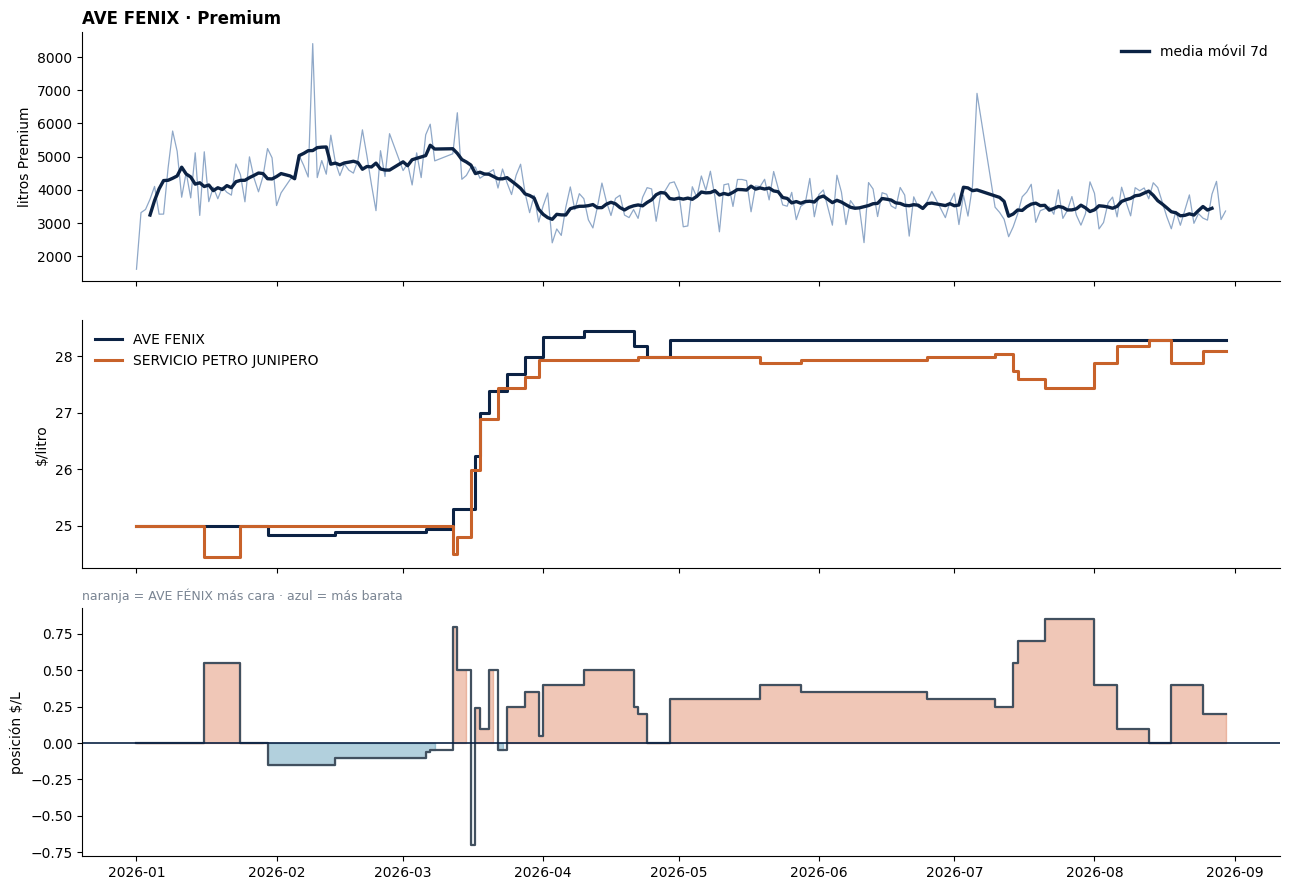

In [5]:
fig, ax = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

ax[0].plot(df[cfg.COL_FECHA], df[P], lw=.9, color="#8FA8C8")
ax[0].plot(df[cfg.COL_FECHA], df[P].rolling(7, center=True).mean(),
           lw=2.4, color="#0B2244", label="media móvil 7d")
ax[0].set_ylabel("litros Premium"); ax[0].legend(frameon=False)
ax[0].set_title(f"{ESTACION} · Premium", loc="left", fontweight="bold")

ax[1].step(df[cfg.COL_FECHA], df[COL_PRE_P], where="post", lw=2.2,
           color="#0B2244", label=ESTACION)
ax[1].step(df[cfg.COL_FECHA], df["precio_comp"], where="post", lw=2.2,
           color="#C8622A", label=COMPETIDOR)
ax[1].set_ylabel("$/litro"); ax[1].legend(frameon=False)

ax[2].fill_between(df[cfg.COL_FECHA], 0, df["pos"], step="post",
                   where=df["pos"] >= 0, color="#D45F31", alpha=.35)
ax[2].fill_between(df[cfg.COL_FECHA], 0, df["pos"], step="post",
                   where=df["pos"] < 0, color="#247BA0", alpha=.35)
ax[2].step(df[cfg.COL_FECHA], df["pos"], where="post", lw=1.6, color="#41505F")
ax[2].axhline(0, color="#0B2244", lw=1.2)
ax[2].set_ylabel("posición $/L")
ax[2].set_title("naranja = AVE FÉNIX más cara · azul = más barata",
                loc="left", fontsize=9, color="#7A8593")

for a in ax:
    for s in ("top", "right"):
        a.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

## 5 · Precios frente a frente · marzo – 31 de agosto

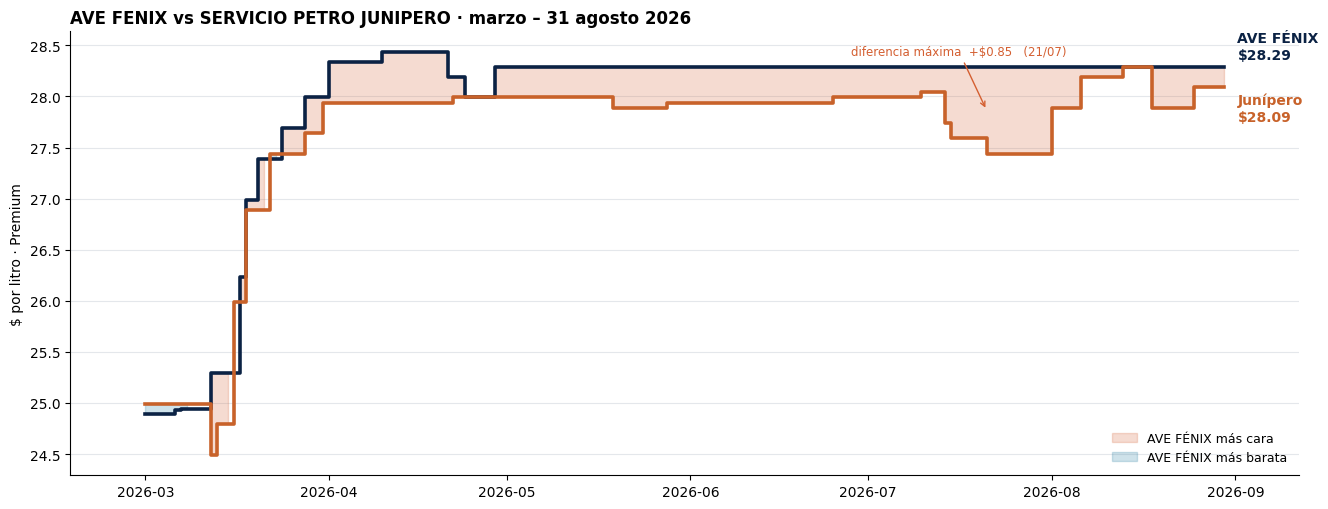

posición media del periodo: +0.333 $/L · días más cara: 153 · más barata: 11 · empate: 10


In [6]:
v = df[(df[cfg.COL_FECHA] >= "2026-03-01") &
        (df[cfg.COL_FECHA] <= "2026-08-31")].copy()

fig, ax = plt.subplots(figsize=(13.5, 5.2))
ax.fill_between(v[cfg.COL_FECHA], v[COL_PRE_P], v["precio_comp"], step="post",
                where=v[COL_PRE_P] >= v["precio_comp"],
                color="#D45F31", alpha=.22, label="AVE FÉNIX más cara")
ax.fill_between(v[cfg.COL_FECHA], v[COL_PRE_P], v["precio_comp"], step="post",
                where=v[COL_PRE_P] < v["precio_comp"],
                color="#247BA0", alpha=.22, label="AVE FÉNIX más barata")
ax.step(v[cfg.COL_FECHA], v[COL_PRE_P], where="post", lw=2.6,
        color="#0B2244", zorder=3)
ax.step(v[cfg.COL_FECHA], v["precio_comp"], where="post", lw=2.6,
        color="#C8622A", zorder=3)

ult = v.iloc[-1]
ax.annotate(f"AVE FÉNIX\n${ult[COL_PRE_P]:.2f}",
            (ult[cfg.COL_FECHA], ult[COL_PRE_P]), xytext=(10, 6),
            textcoords="offset points", color="#0B2244", fontweight="bold", fontsize=10)
ax.annotate(f"Junípero\n${ult['precio_comp']:.2f}",
            (ult[cfg.COL_FECHA], ult["precio_comp"]), xytext=(10, -24),
            textcoords="offset points", color="#C8622A", fontweight="bold", fontsize=10)

pmax = v.loc[v["pos"].idxmax()]
ax.annotate(f"diferencia máxima  +${pmax['pos']:.2f}   ({pmax[cfg.COL_FECHA]:%d/%m})",
            (pmax[cfg.COL_FECHA], (pmax[COL_PRE_P] + pmax["precio_comp"]) / 2),
            xytext=(-20, 40), textcoords="offset points", fontsize=8.5,
            color="#D45F31", ha="center",
            arrowprops=dict(arrowstyle="->", color="#D45F31", lw=1))

ax.set_ylabel("$ por litro · Premium")
ax.set_title(f"{ESTACION} vs {COMPETIDOR} · marzo – 31 agosto 2026",
             loc="left", fontweight="bold", fontsize=12)
ax.legend(frameon=False, loc="lower right", fontsize=9)
ax.grid(axis="y", color="#E4E7EB", lw=.8); ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.margins(x=.07)
plt.tight_layout(); plt.show()

print(f"posición media del periodo: {v['pos'].mean():+.3f} $/L · "
      f"días más cara: {(v['pos'] > 0).sum()} · más barata: {(v['pos'] < 0).sum()} · "
      f"empate: {(v['pos'] == 0).sum()}")

### 5.1 · Tabla de movimientos del periodo graficado

In [7]:
mov = v[[cfg.COL_FECHA, COL_PRE_P, "precio_comp", "pos", P]].copy()
cambio = (mov[COL_PRE_P].diff() != 0) | (mov["precio_comp"].diff() != 0)
cambio.iloc[0] = True
mov = mov[cambio].rename(columns={cfg.COL_FECHA: "Desde", COL_PRE_P: "AVE FÉNIX",
                                  "precio_comp": "Competencia", "pos": "Posición",
                                  P: "Litros del día"})
mov["Desde"] = mov["Desde"].dt.strftime("%d/%m/%Y")
mov["Más barata"] = np.where(mov["Posición"] > 0, "competencia",
                    np.where(mov["Posición"] < 0, "AVE FÉNIX", "empate"))

print(f"{len(mov)} movimientos entre el 01/03/2026 y el 31/08/2026\n")
print(mov.to_string(index=False, float_format=lambda x: f"{x:9.2f}"))

31 movimientos entre el 01/03/2026 y el 31/08/2026

     Desde  AVE FÉNIX  Competencia  Posición  Litros del día  Más barata
01/03/2026      24.89        24.99     -0.10         4584.07   AVE FÉNIX
06/03/2026      24.93        24.99     -0.06         5659.47   AVE FÉNIX
07/03/2026      24.94        24.99     -0.05         5978.84   AVE FÉNIX
12/03/2026      25.29        24.49      0.80         5090.15 competencia
13/03/2026      25.29        24.79      0.50         6323.51 competencia
16/03/2026      25.29        25.99     -0.70         4682.60   AVE FÉNIX
17/03/2026      26.23        25.99      0.24         4685.23 competencia
18/03/2026      26.99        26.89      0.10         4353.36 competencia
20/03/2026      27.39        26.89      0.50         4526.02 competencia
22/03/2026      27.39        27.44     -0.05         4058.35   AVE FÉNIX
24/03/2026      27.69        27.44      0.25         4215.95 competencia
28/03/2026      27.99        27.64      0.35         3904.78 competencia

## 6 · Modelo

In [8]:
serie_P = est.set_index(cfg.COL_FECHA)[P].astype(float)
ly = serie_P.rolling(7, center=True, min_periods=3).mean().shift(365, freq="D")
df["lts_ly"] = df[cfg.COL_FECHA].map(ly)

d = df.dropna(subset=[P, "lts_ly"]).copy()
d = d[(d[P] > 0) & (d["lts_ly"] > 0)].reset_index(drop=True)
d["ln_medio"]  = np.log(d["p_medio"])
d["ln_propio"] = np.log(d[COL_PRE_P])
d["ln_comp"]   = np.log(d["precio_comp"])


def diseno(frame, cols):
    X = frame[cols].copy()
    X["ln_lts_ly"] = np.log(frame["lts_ly"].astype(float))
    X["Quincena"]  = frame["Quincena"].astype(int)
    X["Festivo"]   = frame["Festivo"].astype(int)
    X["t_c"]       = np.arange(len(frame)) - len(frame) / 2
    dw = pd.get_dummies(frame["Dia_semana"], prefix="D", drop_first=True).astype(int)
    return sm.add_constant(pd.concat([X, dw], axis=1).astype(float))


y = np.log(d[P].astype(float))
X = diseno(d, ["ln_medio", "pos"])
m = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 14})

n_cambios = int((d["precio_comp"].diff() != 0).sum() + (d[COL_PRE_P].diff() != 0).sum())
print(f"n = {int(m.nobs)} días · cambios de precio en la muestra = {n_cambios}")
print(f"R² = {m.rsquared:.3f} · R² ajustado = {m.rsquared_adj:.3f}\n")
print(m.summary().tables[1])

n = 230 días · cambios de precio en la muestra = 39
R² = 0.455 · R² ajustado = 0.425

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.7166      2.716      3.209      0.001       3.393      14.040
ln_medio      -1.2698      0.487     -2.605      0.009      -2.225      -0.315
pos           -0.1153      0.038     -3.023      0.003      -0.190      -0.041
ln_lts_ly      0.4672      0.231      2.023      0.043       0.015       0.920
Quincena      -0.0101      0.021     -0.475      0.635      -0.052       0.032
Festivo       -0.1643      0.069     -2.383      0.017      -0.299      -0.029
t_c           -0.0007      0.000     -1.653      0.098      -0.002       0.000
D_1           -0.0393      0.034     -1.160      0.246      -0.106       0.027
D_2           -0.0475      0.030     -1.584      0.113      -0.106       0.011
D_3           -0.0618      0.042     -1.473  

In [9]:
bm, sm_, pm = m.params["ln_medio"], m.bse["ln_medio"], m.pvalues["ln_medio"]
bp, sp, pp = m.params["pos"], m.bse["pos"], m.pvalues["pos"]

print(f"{'':<26}{'coef':>9}{'EE HAC':>10}{'p':>10}{'IC 95%':>22}")
print("-" * 77)
print(f"{'elasticidad de mercado':<26}{bm:>+9.3f}{sm_:>10.3f}{pm:>10.4f}"
      f"{f'[{bm-1.96*sm_:+.3f}, {bm+1.96*sm_:+.3f}]':>22}")
print(f"{'efecto de posición':<26}{bp:>+9.3f}{sp:>10.3f}{pp:>10.4f}"
      f"{f'[{bp-1.96*sp:+.3f}, {bp+1.96*sp:+.3f}]':>22}")

print(f"\nefecto de posición reexpresado")
for c in (10, 25, 50, 100):
    print(f"  {c:>3} centavos por encima de la competencia -> "
          f"{100*(np.exp(bp*c/100)-1):+6.2f}% de volumen")

                               coef    EE HAC         p                IC 95%
-----------------------------------------------------------------------------
elasticidad de mercado       -1.270     0.487    0.0092      [-2.225, -0.314]
efecto de posición           -0.115     0.038    0.0025      [-0.190, -0.041]

efecto de posición reexpresado
   10 centavos por encima de la competencia ->  -1.15% de volumen
   25 centavos por encima de la competencia ->  -2.84% de volumen
   50 centavos por encima de la competencia ->  -5.60% de volumen
  100 centavos por encima de la competencia -> -10.89% de volumen


### 6.1 · Parametrización alterna: los dos precios por separado

In [10]:
mB = sm.OLS(y, diseno(d, ["ln_propio", "ln_comp"])).fit(
    cov_type="HAC", cov_kwds={"maxlags": 14})

print(f"{'':<24}{'coef':>9}{'EE HAC':>10}{'p':>10}")
print("-" * 55)
for etq, v_ in [("elasticidad propia", "ln_propio"), ("elasticidad cruzada", "ln_comp")]:
    print(f"{etq:<24}{mB.params[v_]:>+9.3f}{mB.bse[v_]:>10.3f}{mB.pvalues[v_]:>10.4f}")

print(f"\nsuma propia + cruzada = {mB.params['ln_propio']+mB.params['ln_comp']:+.3f}")
print(f"elasticidad de mercado = {bm:+.3f}")
print(f"correlación ln(propio), ln(competencia) = {d.ln_propio.corr(d.ln_comp):.4f}")
print(f"R² = {mB.rsquared:.3f}")

                             coef    EE HAC         p
-------------------------------------------------------
elasticidad propia         -3.735     1.017    0.0002
elasticidad cruzada        +2.450     1.064    0.0213

suma propia + cruzada = -1.285
elasticidad de mercado = -1.270
correlación ln(propio), ln(competencia) = 0.9878
R² = 0.456


## 7 · Descomposición del cambio de volumen

Antes = enero–febrero. Después = mayo–agosto. Los efectos se calculan con los coeficientes de la sección 6.

In [11]:
ante = d[d[cfg.COL_FECHA] < "2026-03-01"]
post = d[d[cfg.COL_FECHA] >= "2026-05-01"]

d_ln_medio  = np.log(post.p_medio.mean()) - np.log(ante.p_medio.mean())
d_pos       = post.pos.mean() - ante.pos.mean()
ef_mercado  = bm * d_ln_medio
ef_posicion = bp * d_pos
ef_total    = ef_mercado + ef_posicion
real        = np.log(post[P].mean()) - np.log(ante[P].mean())

print(f"{'':<26}{'antes':>10}{'después':>11}{'cambio':>12}")
print("-" * 59)
print(f"{'precio medio de la zona':<26}{ante.p_medio.mean():>10.2f}"
      f"{post.p_medio.mean():>11.2f}{100*(np.exp(d_ln_medio)-1):>11.1f}%")
print(f"{'posición vs competencia':<26}{ante.pos.mean():>+10.2f}"
      f"{post.pos.mean():>+11.2f}{d_pos:>+12.2f}")
print(f"{'litros Premium / día':<26}{ante[P].mean():>10,.0f}"
      f"{post[P].mean():>11,.0f}{100*(np.exp(real)-1):>11.1f}%")

print(f"\n{'descomposición del volumen':<34}{'%':>10}{'peso':>10}")
print("-" * 54)
print(f"{'efecto nivel de mercado':<34}{100*ef_mercado:>+10.1f}"
      f"{100*ef_mercado/ef_total:>9.0f}%")
print(f"{'efecto posición competitiva':<34}{100*ef_posicion:>+10.1f}"
      f"{100*ef_posicion/ef_total:>9.0f}%")
print("-" * 54)
print(f"{'total explicado':<34}{100*ef_total:>+10.1f}")
print(f"{'observado':<34}{100*(np.exp(real)-1):>+10.1f}")
print(f"{'residual':<34}{100*(real-ef_total):>+10.1f}")

                               antes    después      cambio
-----------------------------------------------------------
precio medio de la zona        24.92      28.10       12.8%
posición vs competencia        +0.02      +0.37       +0.35
litros Premium / día           4,427      3,636      -17.9%

descomposición del volumen                 %      peso
------------------------------------------------------
efecto nivel de mercado                -15.3       79%
efecto posición competitiva             -4.1       21%
------------------------------------------------------
total explicado                        -19.4
observado                              -17.9
residual                                -0.3


## 8 · Mismo modelo aplicado a Regular y Diésel

El precio comparado es el de Premium; se reporta el coeficiente de posición para los tres combustibles.

In [13]:
print(f"{'Combustible':<12}{'b posición':>12}{'EE HAC':>10}{'p':>10}{'n':>7}")
print("-" * 51)
for nombre, col in COLS_LTS.items():
    dd = df.copy()
    s_ = est.set_index(cfg.COL_FECHA)[col].astype(float)
    dd["lts_ly"] = dd[cfg.COL_FECHA].map(
        s_.rolling(7, center=True, min_periods=3).mean().shift(365, freq="D"))
    dd["ln_medio"] = np.log(dd["p_medio"])
    dd = dd.dropna(subset=[col, "lts_ly"])
    dd = dd[(dd[col] > 0) & (dd["lts_ly"] > 0)].reset_index(drop=True)
    mm = sm.OLS(np.log(dd[col].astype(float)), diseno(dd, ["ln_medio", "pos"])).fit(
        cov_type="HAC", cov_kwds={"maxlags": 14})
    print(f"{nombre:<12}{mm.params['pos']:>+12.3f}{mm.bse['pos']:>10.3f}"
          f"{mm.pvalues['pos']:>10.4f}{int(mm.nobs):>7}")

Combustible   b posición    EE HAC         p      n
---------------------------------------------------
Premium           -0.115     0.038    0.0025    230
Regular           +0.024     0.033    0.4711    230
Diesel            +0.088     0.148    0.5525    230


## 9 · Diagnósticos de residuos

Durbin-Watson : 1.450
Breusch-Pagan : p = 0.0011
Jarque-Bera   : p = 0.0000


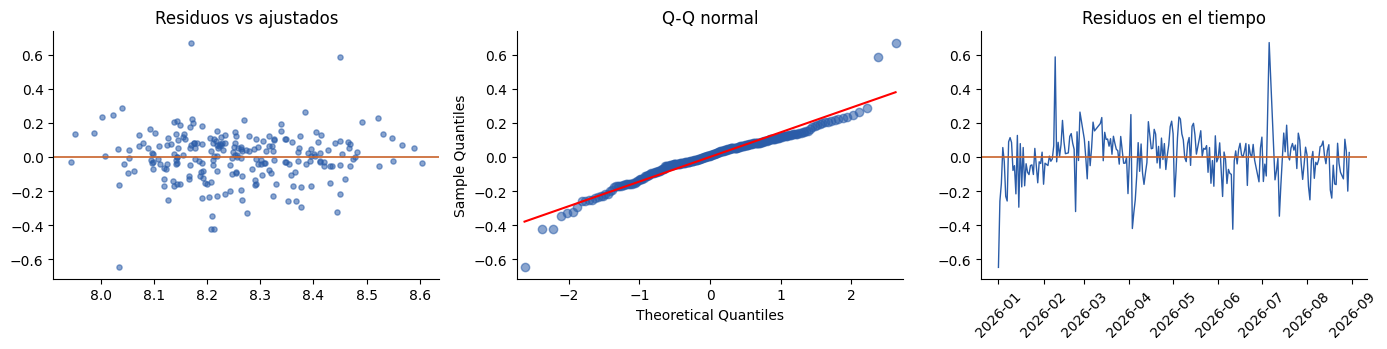

In [14]:
ols = sm.OLS(y, X).fit()
res = ols.resid
print(f"Durbin-Watson : {durbin_watson(res):.3f}")
print(f"Breusch-Pagan : p = {het_breuschpagan(res, X)[3]:.4f}")
print(f"Jarque-Bera   : p = {jarque_bera(res)[1]:.4f}")

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
ax[0].scatter(ols.fittedvalues, res, s=14, alpha=.55, color="#2A5CA8")
ax[0].axhline(0, color="#C8622A", lw=1.2); ax[0].set_title("Residuos vs ajustados")
sm.qqplot(res, line="s", ax=ax[1], markerfacecolor="#2A5CA8",
          markeredgecolor="#2A5CA8", alpha=.55)
ax[1].set_title("Q-Q normal")
ax[2].plot(d[cfg.COL_FECHA], res, lw=1, color="#2A5CA8")
ax[2].axhline(0, color="#C8622A", lw=1.2); ax[2].set_title("Residuos en el tiempo")
ax[2].tick_params(axis="x", rotation=45)
for a in ax:
    for s_ in ("top", "right"):
        a.spines[s_].set_visible(False)
plt.tight_layout(); plt.show()

## 10 · Sensibilidad en pesos

Efecto del volumen únicamente. No incluye el margen que se gana o se cede al mover el precio.

In [12]:
lts = d[P].mean()
print(f"base: {lts:,.0f} L/día · margen supuesto ${MARGEN_L:.2f}/L\n")
print(f"{'posición':>12}{'litros/día':>13}{'litros/mes':>14}{'margen/mes':>16}")
print("-" * 55)
for c in (-30, -20, -10, 0, 10, 20, 30):
    dl = lts * (np.exp(bp * c / 100) - 1)
    print(f"{c:>+9} ¢{dl:>+13.0f}{dl*30:>+14,.0f}{dl*30*MARGEN_L:>+16,.0f}")

base: 3,926 L/día · margen supuesto $2.50/L

    posición   litros/día    litros/mes      margen/mes
-------------------------------------------------------
      -30 ¢         +138        +4,144         +10,360
      -20 ¢          +92        +2,747          +6,867
      -10 ¢          +46        +1,365          +3,414
       +0 ¢           +0            +0              +0
      +10 ¢          -45        -1,350          -3,375
      +20 ¢          -89        -2,684          -6,710
      +30 ¢         -133        -4,003         -10,008
